
## Zdroj dat

Budeme se zabývat predikcí přežití pasažérů Titaniku.
K dispozici máte trénovací data v souboru `data.csv` a data na vyhodnocení v souboru `evaluation.csv`.

#### Seznam příznaků:
* survived - zda pasažér přežil, 0 = Ne, 1 = Ano, **vysvětlovaná proměnná**, kterou chcete predikovat
* pclass - Třída lodního lístku, 1 = první, 2 = druhá, 3 = třetí
* name - jméno
* sex - pohlaví
* age - věk v letech
* sibsp	- počet sourozenců / manželů, manželek na palubě
* parch - počet rodičů / dětí na palubě
* ticket - číslo lodního lístku
* fare - cena lodního lístku
* cabin	- číslo kajuty
* embarked	- místo nalodění, C = Cherbourg, Q = Queenstown, S = Southampton
* home.dest - Bydliště/Cíl

## Pokyny k vypracování

**Body zadání**, za jejichž (poctivé) vypracování získáte **25 bodů**: 
  * V notebooku načtěte data ze souboru `data.csv`. Vhodným způsobem si je rozdělte na podmnožiny, které Vám poslouží pro trénování (trénovací), porovnávání modelů (validační) a následnou predikci výkonnosti finálního modelu (testovací).
    
  * Proveďte základní předzpracování dat:
    * Projděte si jednotlivé příznaky a transformujte je do vhodné podoby pro použití ve vybraném klasifikačním modelu.
    * Podle potřeby si můžete vytvářet nové příznaky (na základě existujících), například tedy můžete vytvořit příznak měřící délku jména atp.
    * Některé příznaky můžete také úplně zahodit.
    * Nějakým způsobem se vypořádejte s chybějícími hodnotami. _Pozor na metodické chyby!_
    * Můžete využívat i vizualizace a vše stručně ale náležitě komentujte.

  
  * Na připravená data postupně aplikujte **rozhodovací strom** a **metodu nejbližších sousedů**, přičemž pro každý z těchto modelů:
    * Okomentujte vhodnost daného modelu pro daný typ úlohy.
    * Vyberte si hlavní hyperparametry k ladění a najděte jejich nejlepší hodnoty.
    * Pro model s nejlepšími hodnotami hyperparametrů spočtěte F1 skóre, nakreslete ROC křivku a určete AUC. _Pozor na metodické chyby!_
    * Získané výsledky vždy řádně okomentujte.

        
  * Ze všech zkoušených možností v předchozím kroku vyberte finální model a odhadněte, jakou přesnost můžete očekávat na nových datech, která jste doposud neměli k dispozici. _Pozor na metodické chyby!_
    
  * Nakonec načtěte vyhodnocovací data ze souboru`evaluation.csv`. Pomocí finálního modelu napočítejte predikce pro tyto data (vysvětlovaná proměnná v nich již není). Vytvořte soubor `results.csv`, ve kterém získané predikce uložíte do dvou sloupců: **ID**, **survived**. Tento soubor též odevzdejte (uložte do repozitáře vedle notebooku).

  * Ukázka prvních řádků souboru `results.csv`:
  
```
ID,survived
1000,0
1001,1
...
```


#### Nahraju data a náhodně je rozdělím na testovací, validační a trénovací

In [1]:
import math
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
%matplotlib inline 

In [2]:
df = pd.read_csv("data.csv")

In [3]:
Xdata = df.drop("survived", axis = 1)
Ydata = df["survived"]
rd_seed = 333
Xtrain, Xtest, Ytrain, Ytest = train_test_split(Xdata, Ydata, test_size=0.4, random_state=rd_seed) 
Xval, Xtest, Yval, Ytest = train_test_split(Xtest, Ytest, test_size=0.5, random_state=rd_seed) 
# Xtest.info()

#### Vytvořim funkci na transformaci dat, kteoru můžu použít i pro testovací data, aby se dala dát do modelu

Rozdělim lidi na ty co maji kabinu a ty co ji nemaji (předpokládám, že chybějící zápis o kabině znamená, že člověk kabinu neměl). Tento číselný příznak můžu použít i pro knn bez dummies sloupců, protože má jen 2 hodnoty a tím pádem nebudu zhoršovat prokletí dimenzionality.

In [4]:
def convert_cabin(data):
    if data == "somerandomvaluethatdoesntmatchanythingactual":
        data = "0"
    else:
        data = "1"
    return data

def cabinToInt(data):
    data["cabin"] = data["cabin"].fillna("somerandomvaluethatdoesntmatchanythingactual")
    data["cabin"] = data["cabin"].apply(convert_cabin)
    data["cabin"] = data["cabin"].astype("int")
    return data

In [5]:
def convertSex(data):
    if data == "male":
         data = "0"
    else:
        data = "1"
    return data
        
def sexToInt(data):
    data["sex"] = data["sex"].apply(convertSex)
    data["sex"] = data["sex"].astype("int")
    return data

In [6]:
def makeCategoric(data):
    data["embarked"]=data["embarked"].astype("category")
    return data

Zahodím sloupce, které nemají vliv na výsledek

In [7]:
def dropData(data):
    data = data.drop("ticket", axis = 1)
    data = data.drop("home.dest", axis = 1)
    data = data.drop("name", axis = 1)
    data = data.drop("ID", axis = 1)
    return data
    

Doplním chybějící data průměrem/mediánem z trénovacích dat.

In [8]:
def replaceNaN(data):
    mean_age = Xtrain["age"].mean()
    data["age"] = data["age"].fillna(mean_age)

    mid_fare = Xtrain["fare"].median()
    data["fare"] = data["fare"].fillna(mid_fare)
    return data


Pro kategorická data s málo hodnotami které se nedají seřadit vytvořím dummy příznaky, abych je mohl použít i pro knn.

In [9]:
def joinDummies(data):
    encoding1 = pd.get_dummies(data['embarked'])

    for value in data['embarked'].value_counts().index: 
        encoding1[value] = encoding1[value].astype('category').cat.codes

    data = data.drop(columns=['embarked'])
    data = data.join(encoding1)
    
    return data

In [10]:
def parseData(data):
    data = makeCategoric(data)
    data = dropData(data)
    data = replaceNaN(data)
    data = cabinToInt(data)
    data = joinDummies(data)
    data = sexToInt(data)
    return data
    

In [11]:
Xtrain = parseData(Xtrain)
Xval = parseData(Xval)
Xtest = parseData(Xtest)
# Xtest.info()

### STROM

In [12]:
from sklearn.tree import DecisionTreeClassifier
import sklearn.metrics as metrics

Vytvořim různé kombinace hyperparametrů pro strom, ten podle nich naučim a vyberu kombinaci s nejlepším skórem.

In [13]:
from sklearn.model_selection import ParameterGrid
param_grid = {
    'max_depth': range(1,101), 
    'criterion': ['entropy', 'gini']
}
param_comb = ParameterGrid(param_grid)


In [14]:
val_acc = []
train_acc = []
for params in param_comb:
    dtc = DecisionTreeClassifier(max_depth=params['max_depth'], criterion=params['criterion'])
    dtc.fit(Xtrain, Ytrain)
    train_acc.append(metrics.accuracy_score(Ytrain, dtc.predict(Xtrain)))
    val_acc.append(metrics.accuracy_score(Yval, dtc.predict(Xval)))

In [15]:
best_params = param_comb[np.argmax(val_acc)]
best_params

{'max_depth': 3, 'criterion': 'entropy'}

In [16]:
dtc = DecisionTreeClassifier(**best_params)
dtc.fit(Xtrain, Ytrain)


DecisionTreeClassifier(criterion='entropy', max_depth=3)

In [17]:
dtc = DecisionTreeClassifier(**best_params)
dtc.fit(Xtrain, Ytrain)
print('accuracy score (train): {0:.6f}'.format(metrics.accuracy_score(Ytrain, dtc.predict(Xtrain))))
print('accuracy score (validation): {0:.6f}'.format(metrics.accuracy_score(Yval, dtc.predict(Xval))))


accuracy score (train): 0.806667
accuracy score (validation): 0.820000


### KNN

In [18]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

Vyberu, zda je lepší data normalizovat nebo standardizovat nebo nechat původní. Na nich naučím knn model a vyberu ten, který nejlépe skóruje na validačních datech.

In [19]:
scaler = MinMaxScaler()
Xtrain_MinMax = scaler.fit_transform(Xtrain)
Xval_MinMax = scaler.transform(Xval)


In [20]:
scaler = StandardScaler()
Xtrain_Stnd = scaler.fit_transform(Xtrain)
Xval_Stnd = scaler.transform(Xval)


In [21]:
val_acc = []
train_acc = []

val_acc_minMax = []
train_acc_minMax = []

val_acc_stnd = []
train_acc_stnd = []

for k in range(2,20):
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(Xtrain, Ytrain)
    val_acc.append(knn.score(Xval, Yval))
    train_acc.append(knn.score(Xtrain, Ytrain))

for k in range(2,20):
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(Xtrain_MinMax, Ytrain)
    val_acc_minMax.append(knn.score(Xval_MinMax, Yval))
    train_acc_minMax.append(knn.score(Xtrain_MinMax, Ytrain))
    
for k in range(2,20):
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(Xtrain_Stnd, Ytrain)
    val_acc_stnd.append(knn.score(Xval_Stnd, Yval))
    train_acc_stnd.append(knn.score(Xtrain_Stnd, Ytrain))

In [22]:
print(max(val_acc_minMax))
val_acc_minMax.index(max(val_acc_minMax)) + 2

0.835


14

In [23]:
print(max(val_acc_stnd))
val_acc_stnd.index(max(val_acc_stnd)) + 2

0.82


14

In [24]:
print(max(val_acc))
val_acc.index(max(val_acc)) + 2

0.725


6

Nejlépe skóruje normalizace s 14 sousedama.

In [25]:
knn = KNeighborsClassifier(n_neighbors = val_acc_minMax.index(max(val_acc_minMax)) + 2)
knn.fit(Xtrain_MinMax, Ytrain)

KNeighborsClassifier(n_neighbors=14)

### F1 score 

In [26]:
# matrix
# TN FP
# FN TP

import sklearn.metrics as metrics

In [27]:
def countF1(matrix):
    TPR = matrix[1,1]/(matrix[1,1] + matrix[1,0])
    PPV = matrix[1,1]/(matrix[1,1] + matrix[0,1])
    F1 = 2*PPV*TPR/(PPV+TPR)
    return F1

In [28]:
matDtc = metrics.confusion_matrix(Yval, dtc.predict(Xval))
F1_dtc = countF1(matDtc)
F1_dtc

0.7777777777777778

In [29]:
matKnn = metrics.confusion_matrix(Yval, knn.predict(Xval_MinMax))
F1_knn = countF1(matKnn)
F1_knn

0.7692307692307692

Dataset je poměrně vyvážený, takže F1 skore nebude potřeba.

In [30]:
df.groupby("survived").size()

survived
0    602
1    398
dtype: int64

### ROC

Vytvořím AUC a ROC křivku stejně jako na cviku 5.

In [31]:
y_pred_proba = dtc.predict_proba(Xval)
AUC = metrics.roc_auc_score(Yval, y_pred_proba[:,1])
AUC

0.87

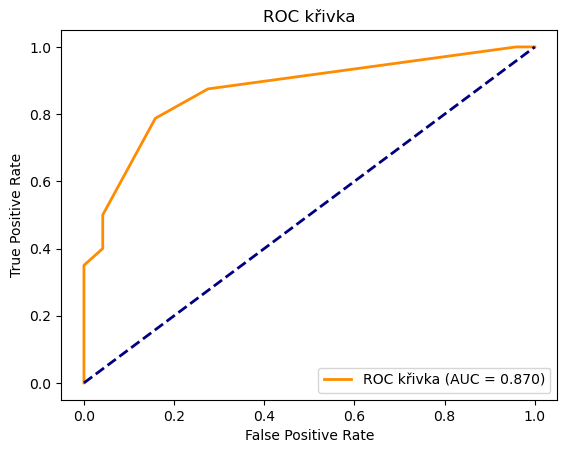

In [32]:
p1_hat = y_pred_proba[:,1]
fpr, tpr, thresholds = metrics.roc_curve(Yval, p1_hat)
plt.plot(fpr, tpr, color="darkorange", lw=2, label = f"ROC křivka (AUC = {AUC:.3f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC křivka")
plt.legend(loc="lower right")
plt.show()

In [33]:
y_pred_proba = knn.predict_proba(Xval_MinMax)
AUC = metrics.roc_auc_score(Yval, y_pred_proba[:,1])
AUC

0.89296875

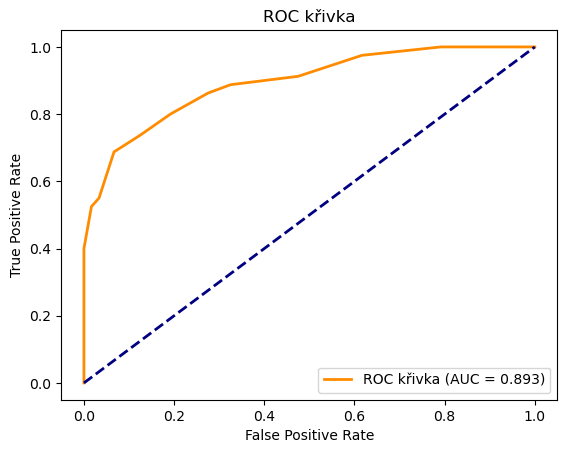

In [34]:
p1_hat = y_pred_proba[:,1]
fpr, tpr, thresholds = metrics.roc_curve(Yval, p1_hat)
plt.plot(fpr, tpr, color="darkorange", lw=2, label = f"ROC křivka (AUC = {AUC:.3f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC křivka")
plt.legend(loc="lower right")
plt.show()

### Finální volba

Vyberu nejlepší model na základě přesnosti na validačních datech - vyhraje KNN s 14 sousedy.
Vyzkouším tento model na testovacích datech.

In [35]:
Xtest_minMax = scaler.transform(Xtest)

print('accuracy score test data:', knn.score(Xtest_minMax, Ytest))

accuracy score test data: 0.75


### Final csv

In [36]:
evaluation = pd.read_csv("evaluation.csv")
result = evaluation['ID']
evaluation = parseData(evaluation)

In [37]:
evaluation = scaler.transform(evaluation)
survivedcol = knn.predict(evaluation)

In [38]:
result = pd.DataFrame(result)

In [39]:
result.insert(1, "survived",0)
result['survived'] = survivedcol
result

,ID,survived
0,1000,0
1,1001,1
2,1002,1
3,1003,0
4,1004,1
...,...,...
304,1304,0
305,1305,0
306,1306,0
307,1307,1


In [40]:
result.to_csv("results.csv", index=False)